# Packages

In [ ]:
import scanpy as sc
import pandas as pd
import numpy as np

# plotting
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text

# Loading the data

This notebook contains the code to generate the plots for the spleen γδ-T-cells dataset, meaning figure 3 c, d, e, f, g, and h. For this purpose we need to load the spleen γδ-T-cells dataset, which is dowloadable at: **provide link** 

In [2]:
spleen_gd = sc.read_h5ad('/media/david/DiskExtension/Collaborations/GFI1_Canada/datasets_publication_v1/spleen_gdT.h5ad')

spleen_gd

AnnData object with n_obs × n_vars = 34738 × 18307
    obs: 'sorted_cell_type', 'batch', 'organ', 'hto_classification', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'leiden', 'genotype', 'mouse', 'cell_type'
    var: 'ribo', 'gm', 'mt', 'mean', 'std', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: '1v0', 'batch_colors', 'cell_type_updated_colors', 'deg_genotype', 'dendrogram_cell_type', 'dendrogram_leiden', 'genotype_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'log1p_norm', 'raw_counts', 'scaled'
    obsp: 'connectivities', 'distances'

# Figure 3

## c)

In [3]:
colors = [
    '#66c5cc','#f6cf71','#f89c74',
    '#dcb0f2','#87c55f','#9eb9f3',
    '#fe88b1','#c9db74','#8be0a4',
    '#b497e7','#d3b484','#b3b3b3',
    '#89fade','#817157','#132b58'
]
cluster_colors = {
    f'{i}': colors[i] for i in range(15)
}

Text(0.5, 1.0, 'Clusters')

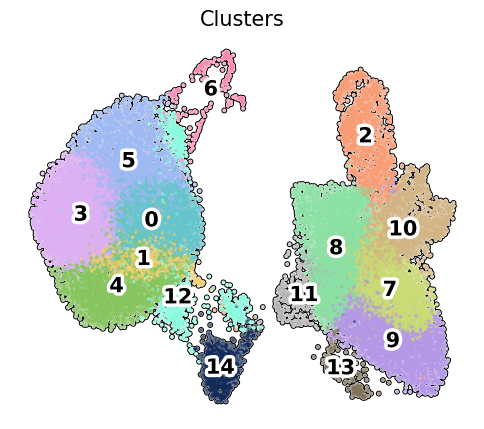

In [4]:
fig, axes = plt.subplots(1,1, figsize=(6,5))

sc.pl.umap(
    spleen_gd,
    color='leiden',
    legend_loc='on data',
    palette=cluster_colors,
    size=25,
    add_outline=True,
    legend_fontoutline=5,
    legend_fontsize=15,
    frameon=False,
    ax=axes, show=False,
)

axes.set_title(
    'Clusters',
    fontsize=15
)

# plt.savefig(
#     '/media/david/DiskExtension/Collaborations/GFI1_Canada/figures_paper_v1/spleen_data/spleen_umap_cluster.pdf',
#     bbox_inches='tight'
# )

## d)

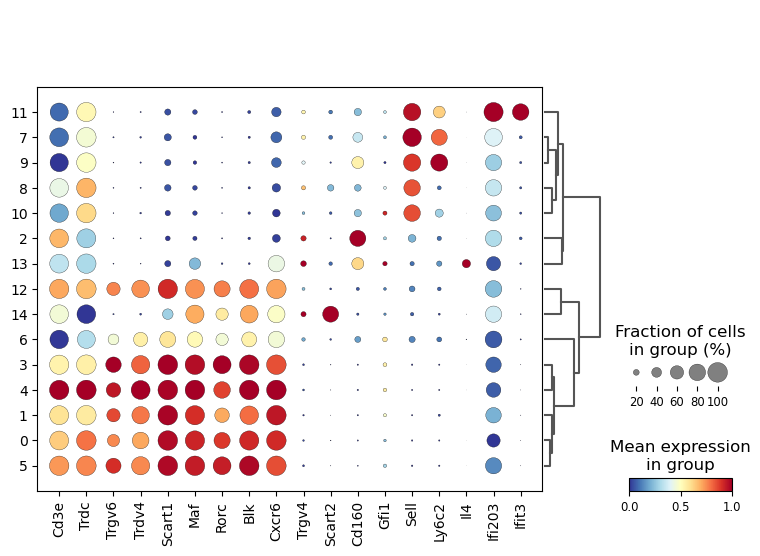

In [5]:
genes = [
    'Cd3e', 'Trdc', 
    'Trgv6', 'Trdv4', 'Scart1', 'Maf', 'Rorc', 'Blk', 'Cxcr6', 
    'Trgv4', 'Scart2', 
    'Cd160', 'Gfi1',
    'Sell', 'Ly6c2', 
    'Il4',
    'Ifi203', 'Ifit3'
]

fig = sc.pl.dotplot(
    spleen_gd,
    var_names=genes,
    groupby='leiden',
    cmap='RdYlBu_r',
    standard_scale='var',
    # Return figure for customization
    return_fig=True,
    dendrogram=True
)

axes = fig.get_axes()

axes['mainplot_ax'].tick_params('x', labelsize=10)
axes['mainplot_ax'].tick_params('y', labelsize=10)

axes['size_legend_ax'].title.set_fontsize(12)
axes['color_legend_ax'].title.set_fontsize(12)

# plt.savefig(
#     '/media/david/DiskExtension/Collaborations/GFI1_Canada/figures_paper_v1/spleen_data/spleen_dotplot.pdf',
#     bbox_inches='tight'
# )

## e)

In [6]:
cell_type_colors = {
    'Trgv6+': '#a6cee3',
    'Cd160+': '#e31a1c',
    'Sell+ Ly6c2+': '#b2df8a',
    'Sell+ Ly6c2-': '#33a02c',
    'Il4+': '#fb9a99',
    'Trgv4+': '#1f78b4',
    'IFN responding': '#fdbf6f',
    'cycling': '#ff7f00'
}

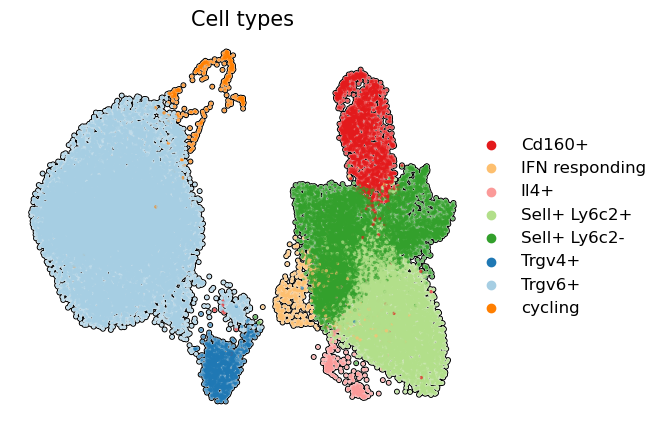

In [7]:
fig, axes = plt.subplots(1,1, figsize=(6,5))

sc.pl.umap(
    spleen_gd,
    color='cell_type',
    palette=cell_type_colors,
    size=25,
    add_outline=True,
    legend_fontoutline=5,
    legend_fontsize=15,
    frameon=False,
    ax=axes, show=False,
)

axes.set_title(
    'Cell types',
    fontsize=15
)

axes.legend(
    loc='center right',
    bbox_to_anchor=(1.4, 0.5),
    title=None,
    fontsize=12,
    frameon=False
)

# plt.savefig(
#     '/media/david/DiskExtension/Collaborations/GFI1_Canada/figures_paper_v1/spleen_data/spleen_umap_celltypes.pdf',
#     bbox_inches='tight'
# )

## f)

In [8]:
genotype_colors = {
    'ko': '#008000',
    'wt': '#a0a0a4'
}

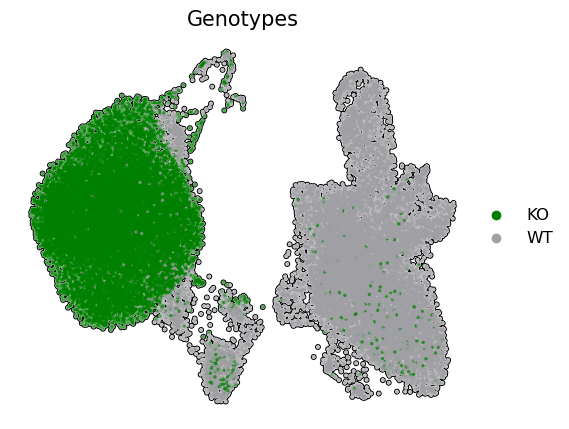

In [9]:
fig, axes = plt.subplots(1,1, figsize=(6,5))

sc.pl.umap(
    spleen_gd,
    color='genotype',
    palette=genotype_colors,
    size=25,
    add_outline=True,
    legend_fontoutline=5,
    legend_fontsize=15,
    frameon=False,
    ax=axes, show=False,
)

axes.set_title(
    'Genotypes',
    fontsize=15
)

# Extract legend handles and labels to capitalize the labels
handles, labels = axes.get_legend_handles_labels()

labels = [label.upper() for label in labels]

axes.legend(
    handles,
    labels,
    loc='center right',
    bbox_to_anchor=(1.2, 0.5),
    title=None,
    fontsize=12,
    frameon=False
)

# plt.savefig(
#     '/media/david/DiskExtension/Collaborations/GFI1_Canada/figures_paper_v1/spleen_data/spleen_umap_genotype.pdf',
#     bbox_inches='tight'
# )

## g)

In order to plot the distribution of cell types across genotype, we first have to extract the cells the and the respective metadata from the anndata object, count the cells per group and then normalize the value by genotype by dividing by the total number of cells in the specific genotype.

In [10]:
# Extract cells and their metadata
df_barplot = sc.get.obs_df(
    spleen_gd,
    keys=['genotype', 'cell_type'],
)

df_barplot = (
    df_barplot
    # Count cells by genotype and cell type
    .groupby(['genotype', 'cell_type'], observed=True)
    .size()
    .reset_index(name='count')
    # Normalize by genotype and convert to percentage
    .assign(
        count_normalized=lambda x: x['count'] / x.groupby('genotype', observed=True)['count'].transform('sum') * 100
    )
)

For simplicity we draw the barplot using the in-built pandas funtion on a wide format of the dataframe, where the columns are the cell types and the rows are the genotypes.

<positron-console-cell-11>:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


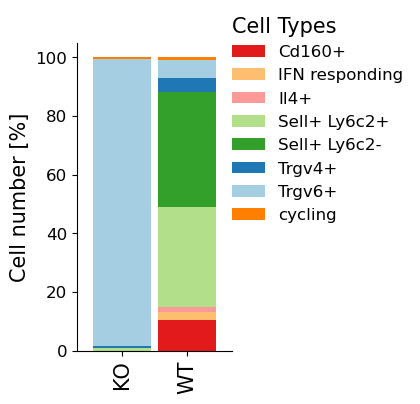

In [11]:
p1 = (
    df_barplot
    # Pivoting data frame from long to wide
    .pivot(
        index='genotype',
        columns='cell_type',
        values='count_normalized'
    )
    # Plot it using pandas in-built function
    .plot(
        kind='bar', 
        stacked=True,
        width=0.9,
        color=cell_type_colors,
        figsize=(2,4)
    )
)


p1.legend(
    loc='center left',
    bbox_to_anchor=(0.9, 0.75),
    title='Cell Types',
    fontsize=12,
    title_fontsize=15,
    frameon=False,
    alignment='left'
)

p1.set_ylabel('Cell number [%]', fontsize=15)
p1.set_yticklabels([0,20,40,60,80,100], fontsize=12)
p1.set_xlabel('')
p1.set_xticklabels(['KO', 'WT'], fontsize=15)

p1.spines['right'].set_visible(False)
p1.spines['top'].set_visible(False)

# plt.savefig(
#     '/media/david/DiskExtension/Collaborations/GFI1_Canada/figures_paper_v1/lung_data/lung_wt_cd3_barplot_celltypes.pdf',
#     bbox_inches='tight'
# )

## h)

First, we need to extract the differentially expressed genes saved in the uns slot "deg_genotype". These were calculated with the Wilcoxon test on the "log1p_norm" layer. Then, we will find the top and bottom 400 genes (800 in total) to plot. This is done to reduce the noise somewhat. Additionally, we will extract the top and bottom 10 genes to label with text. Then we will extract the expression values from the 'log1p_norm" layer of these 800 genes from the KO cells and take the mean across all cells to visualize it. 

In [12]:
deg_genotype = sc.get.rank_genes_groups_df(spleen_gd, key='deg_genotype', group='ko')

In [22]:
# Extract top and bottom 400 genes
top400 = (
    deg_genotype
    .head(400)
    ['names']
    .to_list()
)

bot400 = (
    deg_genotype
    .tail(400)
    ['names']
    .to_list()
)

# Extract top and bottom 10 genes for labelling
top10 = (
    deg_genotype
    .head(10)
    ['names']
    .to_list()
)

bot10 = (
    deg_genotype
    .tail(10)
    ['names']
    .to_list()
)

# Get expression values of these 800 genes from the KO cells
df_ma_plot = sc.get.obs_df(
    spleen_gd[spleen_gd.obs['genotype'] == 'ko'],
    keys=top400 + bot400,
    layer='log1p_norm'
)

# Take the mean across each gene for all cells (we only included KO cells!)
df_ma_plot = (
    df_ma_plot
    .mean()
    .reset_index()
    .rename(columns={'index': 'gene', 0: 'expression'})
)

Then we combine the data frame containing the expression values with the deg_genotype to have information like adjusted p-value and log fold changes.

In [23]:
df_ma_plot = pd.merge(
    df_ma_plot,
    deg_genotype.rename(columns={'names': 'gene'}),
    on=['gene'],
    how='left'
)

We will also add a column containing the information whether the gene is singnificantly up or down regulated in order to color them in the plot.

In [24]:
df_ma_plot['regulation'] = np.where(
    (df_ma_plot['logfoldchanges'] > 1) & (df_ma_plot['pvals_adj'] < 0.05),
    'up',
    np.where(
        (df_ma_plot['logfoldchanges'] < -1) & (df_ma_plot['pvals_adj'] < 0.05),
        'down',
        'ns'
    )
)

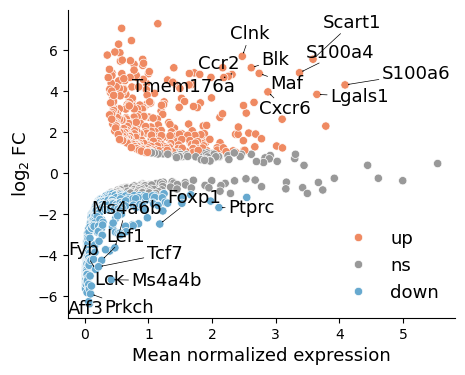

In [26]:
fig, axes = plt.subplots(1,1, figsize=(5,4))

# Plot 
sns.scatterplot(
    data=df_ma_plot,
    x='expression',
    y='logfoldchanges',
    hue='regulation',
    # Custom colors
    palette={'up': '#ef8a62', 'down': '#67a9cf', 'ns': '#999999'},
    ax=axes
)

# Add text labels
texts = []
for i, row in df_ma_plot[df_ma_plot['gene'].isin(top10+bot10)].iterrows():
    texts.append(plt.text(row['expression'], row['logfoldchanges'], row['gene'], fontsize=13))

adjust_text(texts, arrowprops=dict(arrowstyle='->', color='black', lw=0.5))

# Customize legend
axes.legend(
    title=None,
    fontsize=13,
    frameon=False
)

axes.set_ylabel('log$_2$ FC', fontsize=13)
axes.set_xlabel('Mean normalized expression', fontsize=13)

axes.spines['right'].set_visible(False)
axes.spines['top'].set_visible(False)

# plt.savefig(
#     '/media/david/DiskExtension/Collaborations/GFI1_Canada/figures_paper_v1/spleen_data/spleen_md_plot_KOvWT.pdf',
#     bbox_inches='tight'
# )